# **Distance Estimator Model**

## **Project Setup**
### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

### **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [3]:
# Dataset directory
dataset_path = "../dataset/"

# Retrieve all csv files in the dataset folder
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

# Load and merge all datasets
dfs = [pd.read_csv(os.path.join(dataset_path, file)) for file in csv_files]
df = pd.concat(dfs, ignore_index=True)
print("Merge files complete")

Merge files complete


Reading the shape and columns of the dataframe provides information on all the data.

In [4]:
# Print data information
print(f'Number of rows and columns in dataset: {df.shape}')
print()
print(f'Columns in dataset: {df.columns}')

Number of rows and columns in dataset: (42000, 1031)

Columns in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)


## **Data Preparation (Data Cleaning & Data Preprocessing)**

### **Data Cleaning for NaN values**
For data cleaning, we counted the total number of missing (NaN) values in the dataframe. If there is existing missing values, the rows are dropped and the new dataframe is returned to df_cleaned.

In [6]:
missingValCount = df.isnull().sum().sum()

if missingValCount > 0:
    df_cleaned = df.dropna()
    print(f'{missingValCount} missing values found and removed from dataset')
else:
    df_cleaned = df.copy()
    print('No missing values found in dataset')

print(f'Shape before cleaning: {df.shape}')
print(f'Shape of cleaned dataset: {df_cleaned.shape}')

No missing values found in dataset
Shape before cleaning: (42000, 1031)
Shape of cleaned dataset: (42000, 1031)


### **Data Visualization and Data Cleaning**

#### **Target Variable: Range**

Boxplot and histogram is used to visualize the distribution of RANGE. Inter-quartile range (IQR) is also used to determine the count of outliers. We will not be removing outliers as these outliers can be meaningful to the prediction of RANGE.

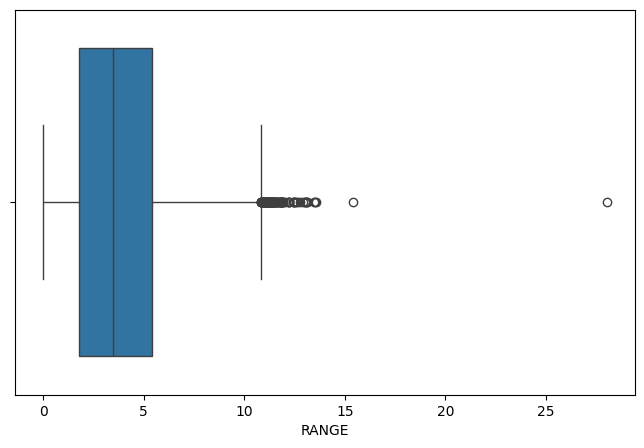

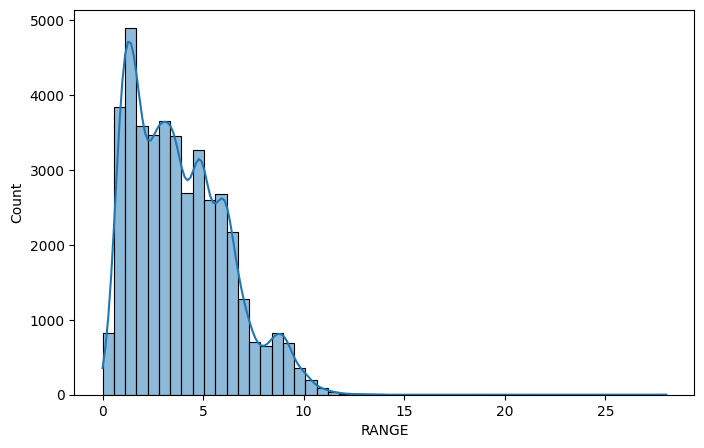

Min: 0.0 Max: 28.02


In [7]:
# Boxplot for RANGE
plt.figure(figsize=(8,5))
sns.boxplot(x=df_cleaned["RANGE"])
plt.show()

# Histogram to check distribution
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned["RANGE"], bins=50, kde=True)
plt.show()

# Check min and max values of RANGE
print("Min:", df_cleaned["RANGE"].min(), "Max:", df_cleaned["RANGE"].max())

In [8]:
Q1 = df_cleaned["RANGE"].quantile(0.25)
Q3 = df_cleaned["RANGE"].quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = df_cleaned[(df_cleaned["RANGE"] < lower_bound) | (df_cleaned["RANGE"] > upper_bound)]
num_outliers = outliers.shape[0]

print("Number of outliers in RANGE:", num_outliers)

Number of outliers in RANGE: 121


#### **Features: FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3**

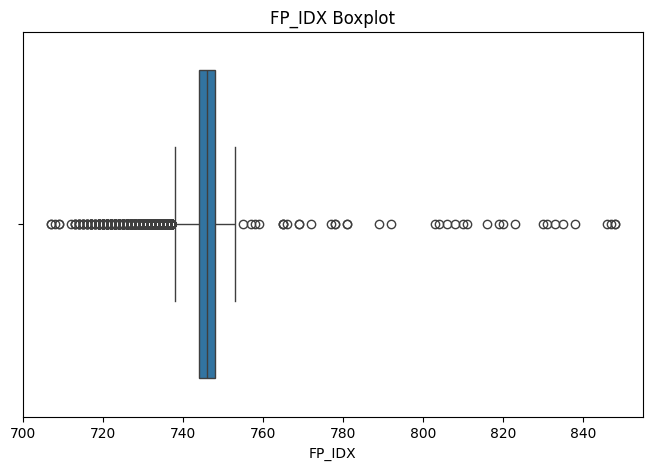

In [9]:
# Plot boxplot for FP_IDX
plt.figure(figsize=(8,5))
sns.boxplot(x=df_cleaned["FP_IDX"])
plt.title("FP_IDX Boxplot")
plt.show()

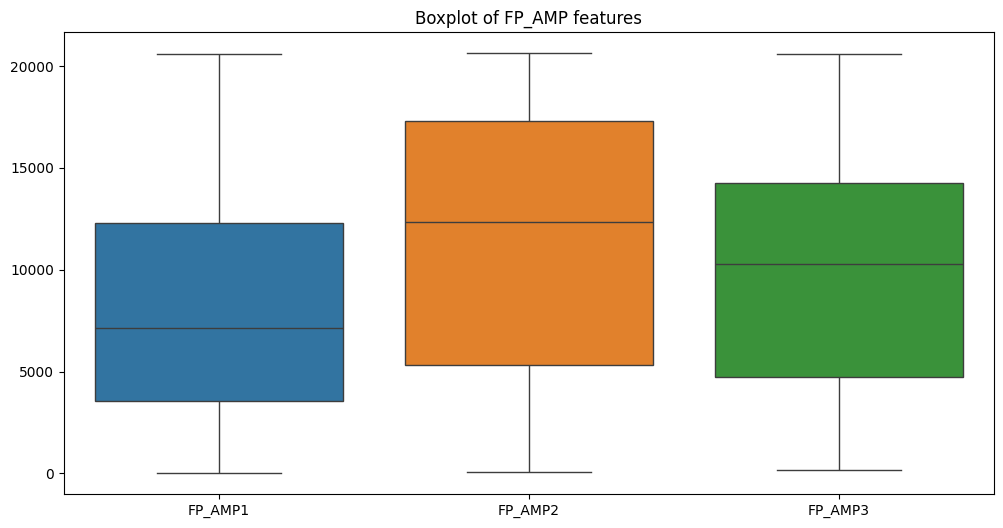

In [10]:
# Plot boxplot for FP_AMP features
# Select features
features = ["FP_AMP1", "FP_AMP2", "FP_AMP3"]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of FP_AMP features")
plt.show()

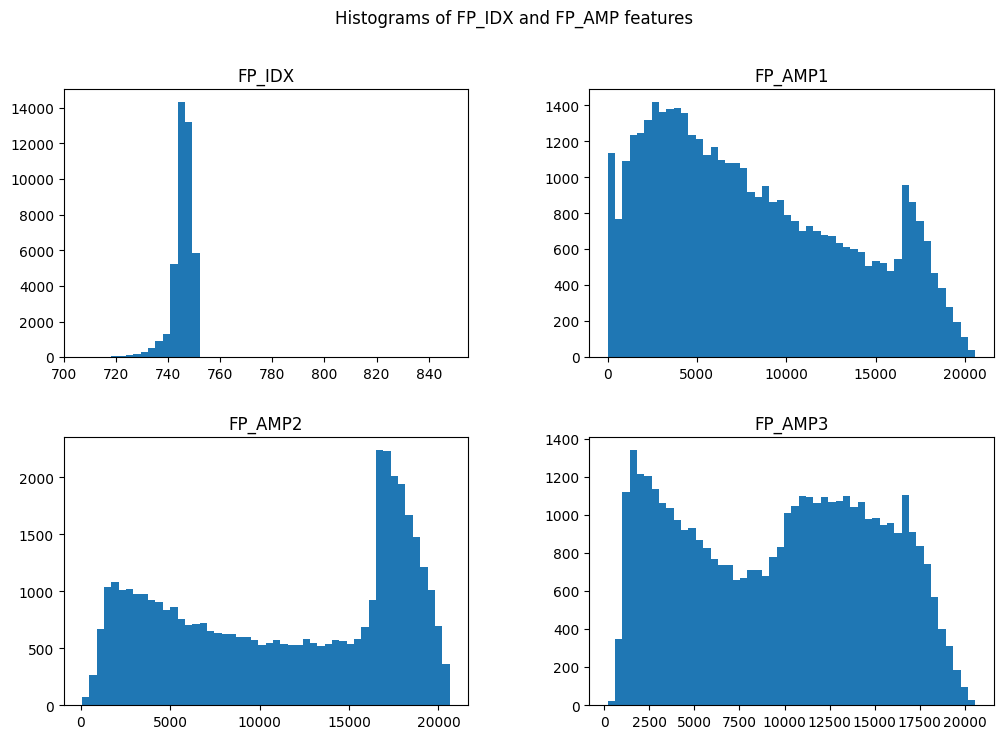

In [11]:
# Plot histogram for FP_IDX and FP_AMP features
# Select features
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

df_cleaned[features].hist(bins=50, figsize=(12,8), grid=False)
plt.suptitle("Histograms of FP_IDX and FP_AMP features")
plt.show()

Here, we only remove **extreme outliers** of FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3 that may highly likely be noise, sensor errors, or unusual environmental interfence.

In [12]:
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

# Determine Q1 and Q2 of features
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df[features] < lower_bound) | (df[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

# Mask for outliers
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df.loc[outlier_mask != True]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Outlier count per feature:
FP_IDX     622
FP_AMP1      0
FP_AMP2      0
FP_AMP3      0
dtype: int64
Total outliers across all features: 622
Dataset shape after removing outliers: (41378, 1031)


#### **Features: STDEV_NOISE, MAX_NOISE**

For STDEV_NOISE and MAX_NOISE, **extreme outliers** are also removed as these can be likely due to sensor glitches or interference.

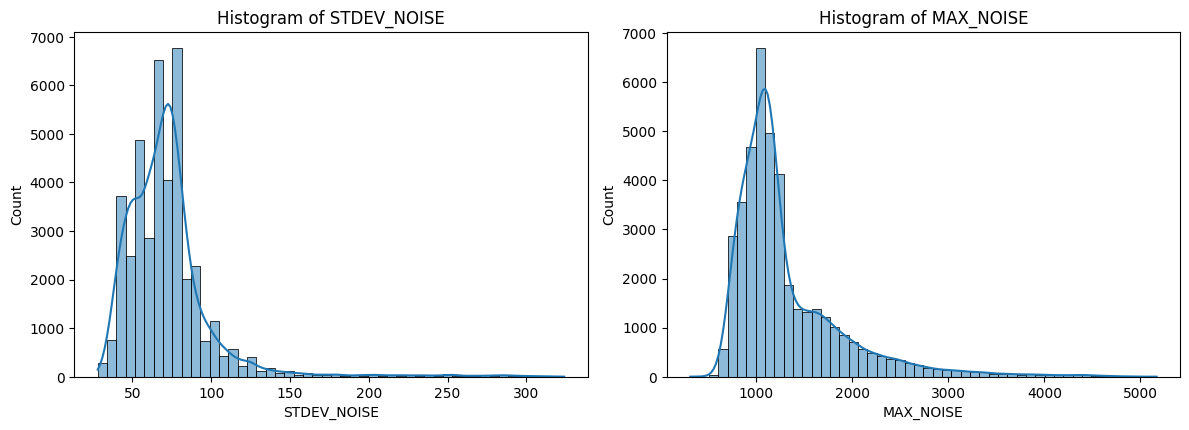

In [13]:
features = ["STDEV_NOISE", "MAX_NOISE"]

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_cleaned[feature], bins=50, kde=True)
    plt.title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()

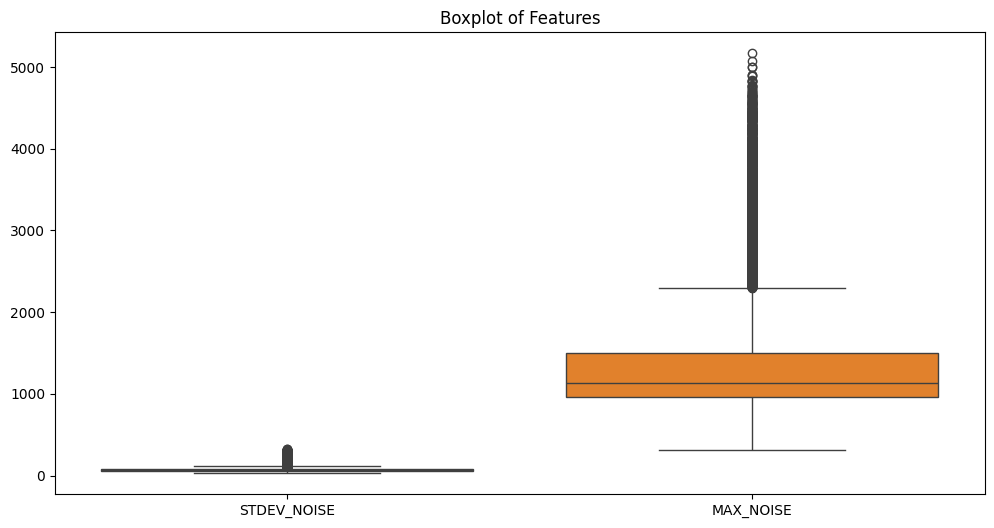

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of Features")
plt.show()

In [16]:
# Determine Q1 and Q2 of features
Q1 = df_cleaned[features].quantile(0.25)
Q3 = df_cleaned[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df_cleaned[features] < lower_bound) | (df_cleaned[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print(f'Current dataset shape: {df_cleaned.shape}')
print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

# Mask for outliers
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df.loc[outlier_mask != True]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Current dataset shape: (41378, 1031)
Outlier count per feature:
STDEV_NOISE    811
MAX_NOISE      871
dtype: int64
Total outliers across all features: 1682
Dataset shape after removing outliers: (40849, 1031)


#### **Feature: CIR_PWR**

For CIR_PWR, we check for impossible values such as **negative and zero values** as Channel Impulse Response power will never be negative.

In [17]:
print(f'Dataset before cleaning: {df_cleaned.shape}')
impossible_cir_pwr_count = (df_cleaned["CIR_PWR"] <= 0).sum()
print(f"Number of CIR_PWR values ≤ 0: {impossible_cir_pwr_count}")

df_cleaned = df_cleaned[df_cleaned["CIR_PWR"] > 0]
print(f"Dataset shape after removing impossible CIR_PWR values: {df_cleaned.shape}")

Dataset before cleaning: (40849, 1031)
Number of CIR_PWR values ≤ 0: 3
Dataset shape after removing impossible CIR_PWR values: (40846, 1031)


#### **Features: RXPACC, FRAME_LEN, PREAM_LEN, CH, BITRATE, PRFR**

For most of these features, the data should be predefined. Hence, we use a histogram to check for multiple unique values. Besides RXPACC which does not have a predefined value, PREAM_LEN has 2 unique values. 

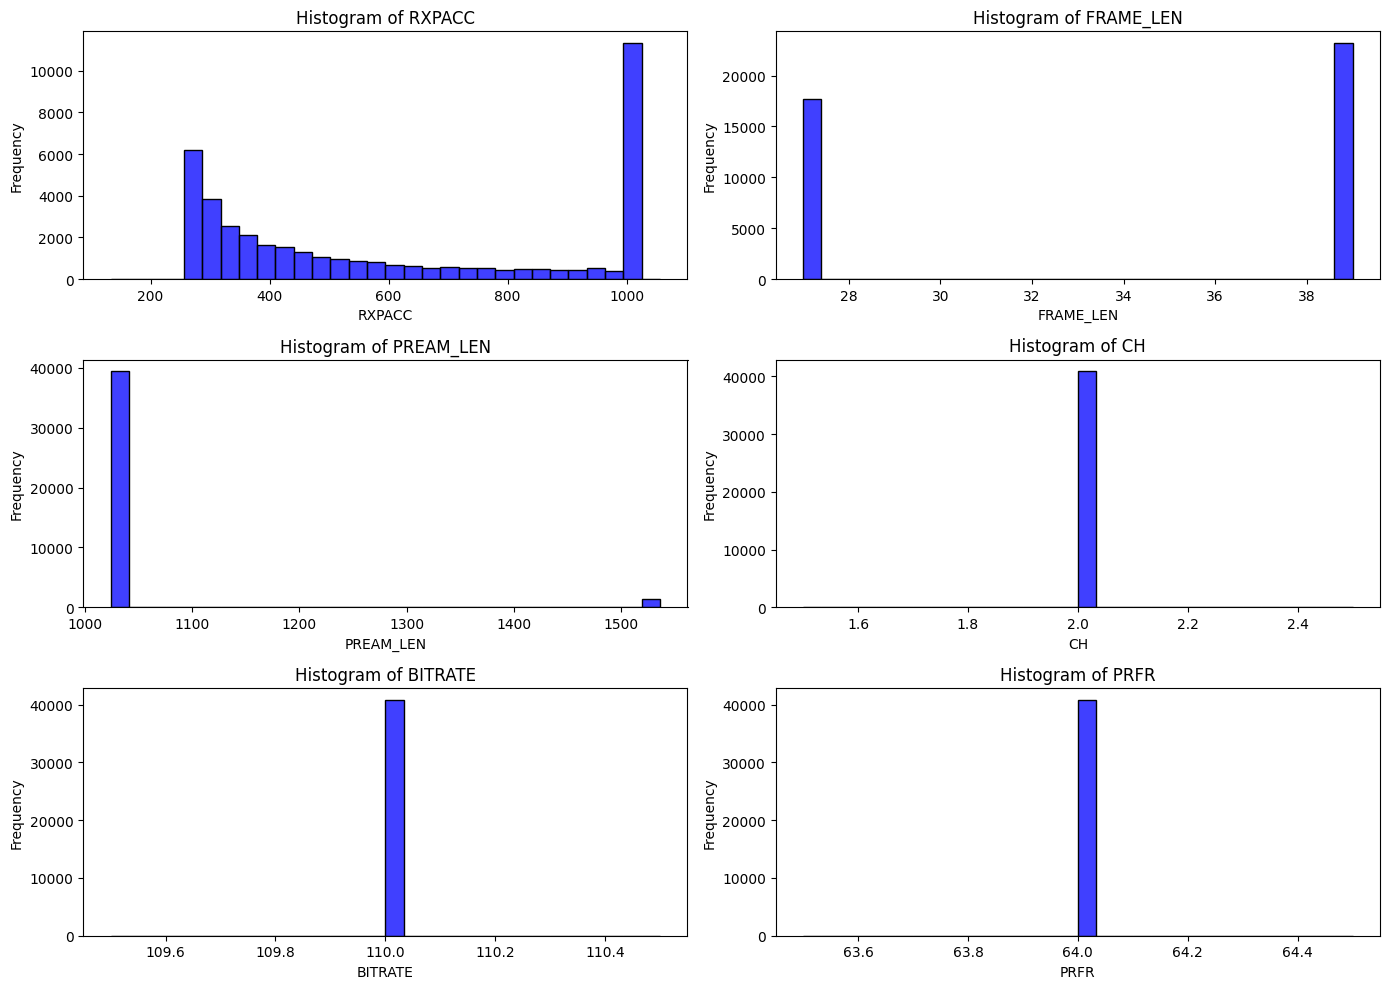

In [18]:
features = ["RXPACC", "FRAME_LEN", "PREAM_LEN", "CH", "BITRATE", "PRFR"]

plt.figure(figsize=(14, 10))

# Loop each feature to plot histogram
for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_cleaned[feature], bins=30, color="blue")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()

To **check for outliers** on RXPACC and PREAM_LEN, we use boxplots to visualize the distribution of data and IQR to count the extreme outliers.

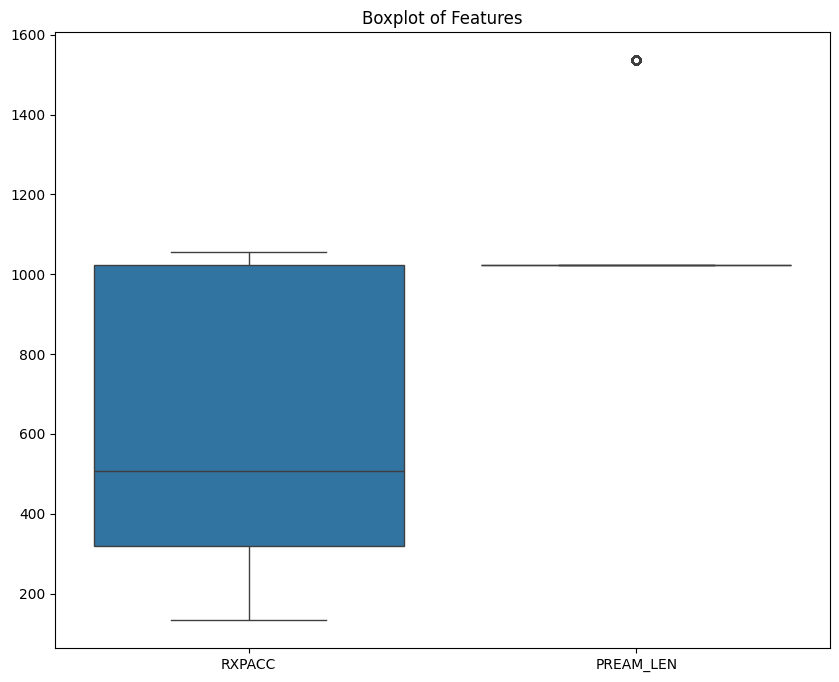

In [19]:
features = ["RXPACC", "PREAM_LEN"]

plt.figure(figsize=(10,8))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of Features")
plt.show()

In [20]:
# Determine Q1 and Q2 of features
Q1 = df_cleaned[features].quantile(0.25)
Q3 = df_cleaned[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df_cleaned[features] < lower_bound) | (df_cleaned[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

Outlier count per feature:
RXPACC          0
PREAM_LEN    1478
dtype: int64
Total outliers across all features: 1478


For futher analysis of PREAM_LEN, we used value_counts(). The output are 2 unique values; 1024.0 and 1536.0. Upon research, 1536 is a valid premeable length so we are **not removing this "outlier"**.

In [21]:
df_cleaned["PREAM_LEN"].value_counts()

PREAM_LEN
1024.0    39368
1536.0     1478
Name: count, dtype: int64

### **Data Visualization and Data Preprocessing**

For features CIR0 to CIR1015 (1016 features), we also did data visualization using heatmap to visualize how the the CIR values behave across multiple data points. After which, we **normalized the CIR values** using RXPACC feature to ensure consistency and reduce bias. Finally, we performed **dimensionality reduction using PCA** to reduce the number of CIR features for effective training of our model. This also removes redundancy and transform highly correlated features into a single feature to improve model performance. 

From the heatmap, we can analyze that the CIR values were **scaled very highly before normalization**, possibly due to noises or differences in signal strength.

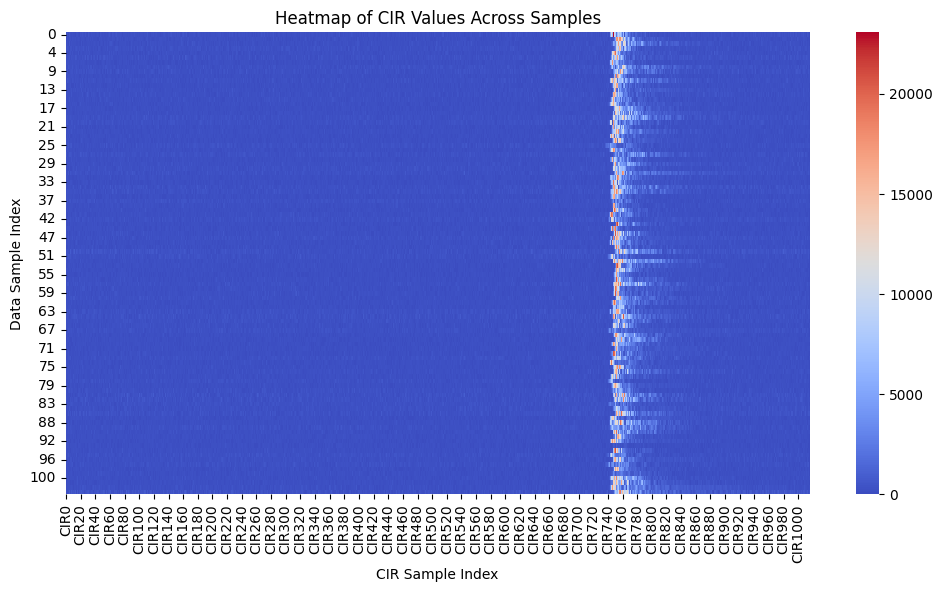

In [22]:
import seaborn as sns

cir_features = [f"CIR{i}" for i in range(1016)]

plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned[cir_features].iloc[:100], cmap="coolwarm")
plt.xlabel("CIR Sample Index")
plt.ylabel("Data Sample Index")
plt.title("Heatmap of CIR Values Across Samples")
plt.show()

#### **Normalization**

After normalization, we can see CIR values that are more comparable with a smaller scale.

In [23]:
# Function to normalize CIR values using RXPACC
def normalize_cir(df):
    df.iloc[:, 15:] = df.iloc[:, 15:].div(df.iloc[:, 9], axis=0)  # Normalize CIR using RXPACC

# Apply normalization to df_cleaned
normalize_cir(df_cleaned)

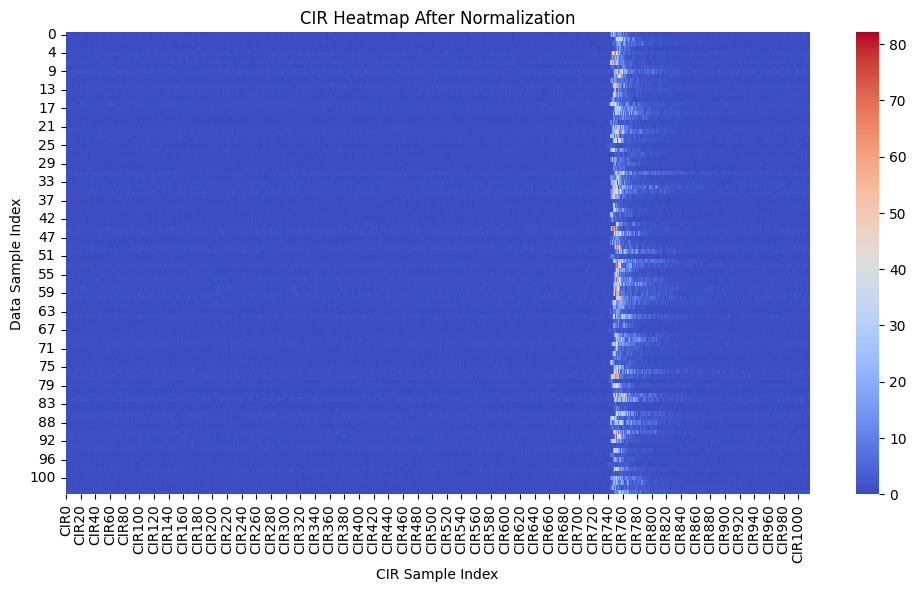

In [24]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.iloc[:100, 15:], cmap="coolwarm")
plt.xlabel("CIR Sample Index")
plt.ylabel("Data Sample Index")
plt.title("CIR Heatmap After Normalization")
plt.show()

#### **Principal Component Analysis (PCA)**

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print(f'Shape before PCA: {df_cleaned.shape}')

# Step 1: Extract CIR Features
cir_features = [f"CIR{i}" for i in range(1016)]
X_cir = df_cleaned[cir_features]  
original_features = X_cir.shape[1]  # Number of features in original dataset

# Step 2: Standardize the Data (PCA requires normalization)
scaler = StandardScaler()
X_cir_scaled = scaler.fit_transform(X_cir)

pca = PCA(n_components=0.95)  # Keep 95% variance
X_cir_pca = pca.fit_transform(X_cir_scaled)
reduced_features = X_cir_pca.shape[1]   # Number of features after PCA

# Print PCA results
print(f"New shape of transformed data: {X_cir_pca.shape}")
print(f"Number of features before PCA: {original_features}")
print(f"Number of features after PCA: {reduced_features}")
print(f"Number of features removed: {original_features - reduced_features}")

Shape before PCA: (40846, 1031)
New shape of transformed data: (40846, 842)
Number of features before PCA: 1016
Number of features after PCA: 842
Number of features removed: 174


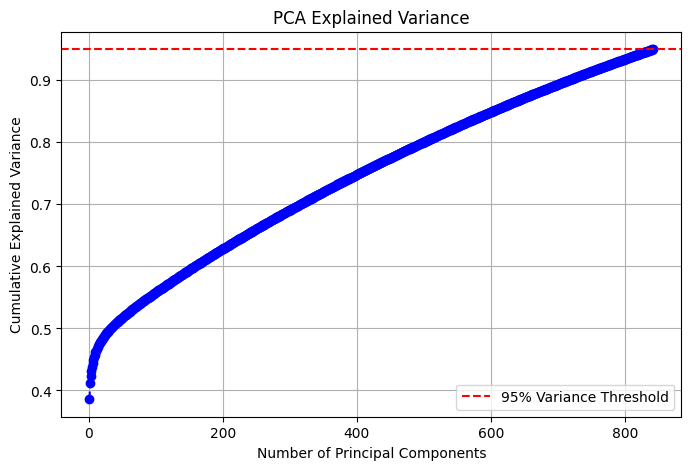

In [26]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()


### **Feature Importance**

To evaluate the feature importance, we explored various visualization graphs such as correlation matrix and mutual information on all features except CIR features. Ultimately, this is to check which features has the **strongest relationship to our target variable**, 'RANGE', such that we can focus on those features and reduce model complexity by removing/ focusing lesser on less important features.

#### **Correlation Matrix**

Correlation matrix detects if the feature has a positive/ negative linear relationship. However, since it can only check for positive/ negative linear relationship, it may not provide an accurate ranking of each feature's importance to our target variable.

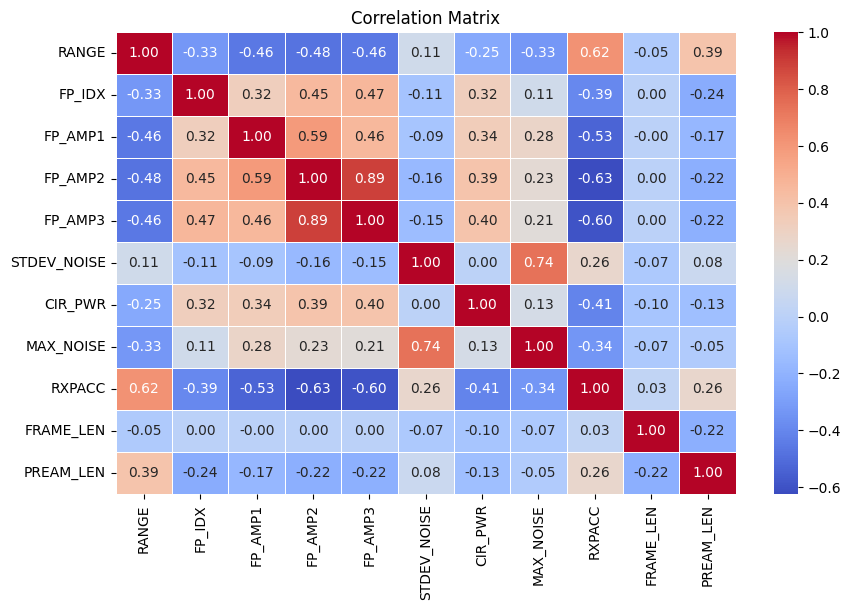

In [27]:
# Shortlisted features to check correlation with each other
features = ['RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
            'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
            'FRAME_LEN','PREAM_LEN']

# Compute the correlation matrix
correlation_matrix = df_cleaned[features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

#### **Mutual Information**

Besides the use of correlation matrix, we used mutual information analysis to further check the relationship of our features with our target variable. Mutual information detects both linear and non-linear relationship and provides a better analysis of which feature contributes to the target variable best. 

Mutual Information Scores (in descending order):
RXPACC         0.376990
MAX_NOISE      0.208224
CIR_PWR        0.178025
FP_AMP2        0.149593
FP_AMP1        0.147927
FP_AMP3        0.136286
STDEV_NOISE    0.091646
PREAM_LEN      0.085356
FP_IDX         0.085164
FRAME_LEN      0.005321
dtype: float64


C:\Users\rames\AppData\Local\Temp\ipykernel_32448\2907315880.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores.index, y=mi_scores.values, palette="viridis")


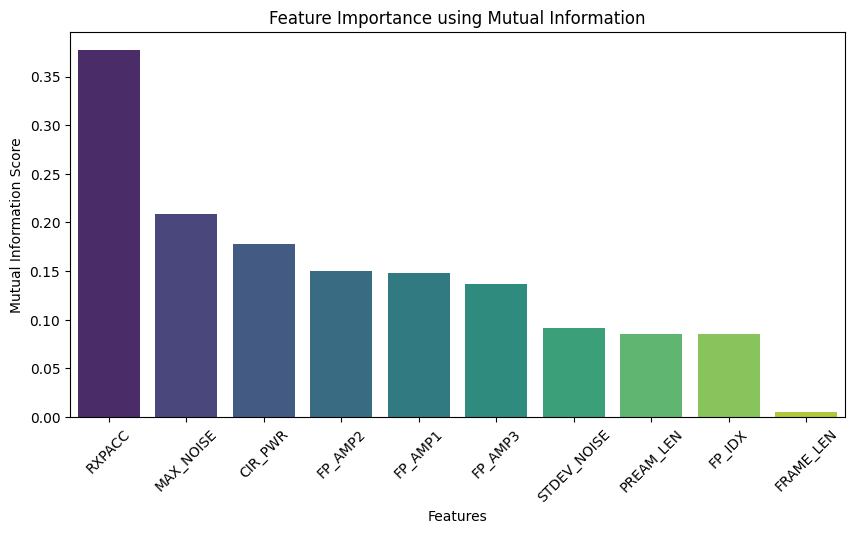

In [28]:
from sklearn.feature_selection import mutual_info_regression

# Features
features = ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
            'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
            'FRAME_LEN','PREAM_LEN']

# Define X as features set
X = df_cleaned[features]

# Define target variable
y = df_cleaned["RANGE"]

# Compute mutual information scores
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=features)

# Sort the scores in descending order and print
mi_scores = mi_scores.sort_values(ascending=False)
print("Mutual Information Scores (in descending order):")
print(mi_scores)

# Plot the scores for better visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores.index, y=mi_scores.values, palette="viridis")
plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Feature Importance using Mutual Information")
plt.xticks(rotation=45)
plt.show()

From the correlation matrix and mutual information results, we can infer that **RXPACC has the strongest relationship with RANGE**. Other **notable features are MAX_NOISE and CIR_PWR** that could possibly provide valuable information when training our model. The **lowest importance features are FRAME_LEN and PREAM_LEN** with 0.007965 and 0.075605 MI scores respectively. Though these features are relatively unimportant, we will kepe these features first to check the model's performance with it. 

## **Data Mining**

### **Checking data**

We check the shape and columns to verify the features we are using for data mining

In [29]:
# Checking dataset original shape 
print(f"Dataset shape before removing features: {df_cleaned.shape}")

# Drop original CIR features
df_cleaned = df_cleaned.drop(columns=cir_features)
print(f"Dataset shape after removing CIR features: {df_cleaned.shape}")

# Load PCA features into a drataframe
df_pca = pd.DataFrame(X_cir_pca, columns=[f"PCA{i+1}" for i in range(reduced_features)])
print(f"Shape of PCA dataset: {df_pca.shape}")

# Add PCA features to the dataframe
df_cleaned = pd.concat([df_cleaned.reset_index(drop=True), df_pca.reset_index(drop=True)], axis=1)

# Print the updated dataframe shape
print()
print(f"Updated dataframe shape: {df_cleaned.shape}")
print(f"Updated dataframe columns: {df_cleaned.columns}")
print(f"NaN values in updated dataframe: {df_cleaned.isnull().sum().sum()}")

Dataset shape before removing features: (40846, 1031)
Dataset shape after removing CIR features: (40846, 15)
Shape of PCA dataset: (40846, 842)

Updated dataframe shape: (40846, 857)
Updated dataframe columns: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'PCA833', 'PCA834', 'PCA835', 'PCA836', 'PCA837', 'PCA838', 'PCA839',
       'PCA840', 'PCA841', 'PCA842'],
      dtype='object', length=857)
NaN values in updated dataframe: 0


### **Data Splitting**

#### **80-20 split**

give ur reasoning here. 1-2 sentence can alr

In [30]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df_cleaned.drop(columns=["RANGE"])
y = df_cleaned["RANGE"]

# Perform 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shapes to verify
print("Training feature set shape:", X_train.shape)
print("Testing feature set shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training feature set shape: (32676, 856)
Testing feature set shape: (8170, 856)
Training labels shape: (32676,)
Testing labels shape: (8170,)


#### **Check for NaN values**

Last check for NaN values before training the model. This is done as we faced NaN values when concatinating df_pca into df_cleaned.

In [31]:
# Check if there are any NaN values in X_train or y_train
print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in y_train:", y_train.isnull().sum())

NaN values in X_train: 0
NaN values in y_train: 0


### **Machine Learning**

Overview of all ur machine learning algos

#### **Linear Regression [change if wrong]**

Linear Regression is simple, interpretable, and fast. It provides a good baseline to compare more complex models against. 

#### **RBF SVR**


Our dataset exhibits non-linear relationships, and RBF SVR can effectively capture these patterns by mapping features into a higher-dimensional space, leading to better prediction accuracy compared to linear models.

### Baseline SVM Parameters for Regression 

- **kernel:** `'rbf'` – Standard choice for non-linear regression.  
- **C:** `1.0` – Default regularization, balancing underfitting and overfitting.  
- **epsilon:** `0.1` – Standard tolerance; can be tuned for precision.  
- **gamma:** `'scale'` – Adapts to data size/variance; recommended since scikit-learn 0.22.  


In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Create the SVR model with RBF kernel
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')  # gamma='scale' is recommended as default

# 3. Train the model
svr_model.fit(X_train_scaled, y_train)

# 4. Predict on test data
y_pred = svr_model.predict(X_test_scaled)




TypeError: got an unexpected keyword argument 'squared'

Time taken : 83 min

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Compute MSE manually
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Manual square root for RMSE
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"SVR RBF Results:\nMSE:{mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR² Score: {r2:.4f}")


SVR RBF Results:
MSE:2.3156
RMSE: 1.5217
MAE: 1.1515
R² Score: 0.5739


The SVR model with the RBF kernel provides a decent baseline, explaining 57% of the variance with moderate 
prediction errors (RMSE: 1.52). There is clear potential for optimization

In [34]:
# Predict on training data
y_train_pred = svr_model.predict(X_train_scaled)

# Predict on test data
y_test_pred = svr_model.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Training metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = train_mse ** 0.5
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = test_mse ** 0.5
test_r2 = r2_score(y_test, y_test_pred)

# Print comparison
print("SVR Model Performance:")
print(f"Training RMSE: {train_rmse:.4f} | Training R²: {train_r2:.4f}")
print(f"Testing  RMSE: {test_rmse:.4f} | Testing  R²: {test_r2:.4f}")


SVR Model Performance:
Training RMSE: 1.2226 | Training R²: 0.7303
Testing  RMSE: 1.5217 | Testing  R²: 0.5739


I trained an SVR model with an RBF kernel and performed hyperparameter tuning. The final model achieved a training R² of 0.73 and a testing R² of 0.57. While there’s a slight gap between training and testing performance, the tuning has provided a solid baseline. Moving forward, I may explore additional techniques like cross-validation or alternative models to further improve the results.

### **Hyperparameter tuning for c**


In [28]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Feasible C values
C_values = [0.5, 3, 5]  # Updated C values

for c in C_values:
    print(f"\nTraining SVR model with C={c}")
    
    # Create SVR model
    svr_model = SVR(kernel='rbf', C=c, epsilon=0.1, gamma='scale')
    
    # Train the model
    svr_model.fit(X_train_scaled, y_train)
    
     # Predict on test data
    y_test_pred = svr_model.predict(X_test_scaled)
    
    # Evaluate the model (TEST DATA ONLY)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    # Print metrics (Test set)
    print(f"SVR Model Performance with C = {c}:")
    print(f"Test MSE  : {mse:.4f}")
    print(f"Test RMSE : {rmse:.4f}")
    print(f"Test MAE  : {mae:.4f}")
    print(f"Test R²   : {r2:.4f}")
    print("----------------------------------------------------------------------------------------" )



Training SVR model with C=0.5
SVR Model Performance with C = 0.5:
Test MSE  : 2.2150
Test RMSE : 1.4883
Test MAE  : 1.1327
Test R²   : 0.5856
----------------------------------------------------------------------------------------

Training SVR model with C=3
SVR Model Performance with C = 3:
Test MSE  : 2.0729
Test RMSE : 1.4398
Test MAE  : 1.1090
Test R²   : 0.6121
----------------------------------------------------------------------------------------

Training SVR model with C=5
SVR Model Performance with C = 5:
Test MSE  : 2.0554
Test RMSE : 1.4337
Test MAE  : 1.1079
Test R²   : 0.6154
----------------------------------------------------------------------------------------


After evaluating different C values, I observed that increasing C improved the model’s performance, with C = 5 giving the best results. It achieved the lowest test RMSE (1.4337) and the highest R² score (0.6154), indicating better predictive accuracy and variance explanation. Based on these metrics, I have decided to proceed with C = 5 as the optimal regularization parameter for my SVR model.

In [29]:
# You already have X_train_scaled and X_test_scaled
# Retrain the model at C=5 if needed
svr_model = SVR(kernel='rbf', C=5, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_scaled, y_train)

# Predict on both training and testing data
y_train_pred = svr_model.predict(X_train_scaled)
y_test_pred = svr_model.predict(X_test_scaled)

# Evaluate training performance
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = train_mse ** 0.5
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate testing performance
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = test_mse ** 0.5
test_r2 = r2_score(y_test, y_test_pred)

# Print train vs test performance
print(f"\nSVR Model Performance for C=5 (Train vs Test):")
print(f"Training RMSE: {train_rmse:.4f} | Training R²: {train_r2:.4f}")
print(f"Testing  RMSE: {test_rmse:.4f} | Testing  R²: {test_r2:.4f}")



SVR Model Performance for C=5 (Train vs Test):
Training RMSE: 0.7439 | Training R²: 0.8974
Testing  RMSE: 1.4337 | Testing  R²: 0.6154


After retraining the SVR model with C = 5, I achieved a training RMSE of 0.7439 and R² of 0.8974, showing a strong fit on the training data. On the test set, the RMSE is 1.4337 with an R² of 0.6154, indicating the model generalizes reasonably well. The performance gap between training and testing suggests a slight overfitting, but overall, C = 5 offers a good balance of accuracy and generalization for my current model. Therefore, I’ve chosen C = 5 as the final parameter for this SVR model.

### **Hyperparmeter tuning for epsilon**


In [30]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Scale the features (optional if already done)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Fixed C
fixed_C = 5.0

# 3. Feasible epsilon values to try
epsilon_values = [0.01, 0.1, 0.5, 1.0]

# 4. Iterate over epsilon values
for eps in epsilon_values:
    print(f"\nTraining SVR Model with C={fixed_C} and epsilon={eps}")

    # Create the SVR model with fixed C and varying epsilon
    svr_model = SVR(kernel='rbf', C=fixed_C, epsilon=eps, gamma='scale')
    
    # Train the model
    svr_model.fit(X_train_scaled, y_train)
    
    # Predict on test data
    y_test_pred = svr_model.predict(X_test_scaled)
    
    # Evaluate the model (TEST DATA ONLY for hyperparameter tuning)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    # Print metrics (Test set)
    print(f"SVR Model Performance with epsilon = {eps}:")
    print(f"Test MSE  : {mse:.4f}")
    print(f"Test RMSE : {rmse:.4f}")
    print(f"Test MAE  : {mae:.4f}")
    print(f"Test R²   : {r2:.4f}")
    print("-" * 60)



Training SVR Model with C=5.0 and epsilon=0.01
SVR Model Performance with epsilon = 0.01:
Test MSE  : 2.0541
Test RMSE : 1.4332
Test MAE  : 1.1054
Test R²   : 0.6157
------------------------------------------------------------

Training SVR Model with C=5.0 and epsilon=0.1
SVR Model Performance with epsilon = 0.1:
Test MSE  : 2.0554
Test RMSE : 1.4337
Test MAE  : 1.1079
Test R²   : 0.6154
------------------------------------------------------------

Training SVR Model with C=5.0 and epsilon=0.5
SVR Model Performance with epsilon = 0.5:
Test MSE  : 2.0754
Test RMSE : 1.4406
Test MAE  : 1.1272
Test R²   : 0.6117
------------------------------------------------------------

Training SVR Model with C=5.0 and epsilon=1.0
SVR Model Performance with epsilon = 1.0:
Test MSE  : 2.1461
Test RMSE : 1.4650
Test MAE  : 1.1719
Test R²   : 0.5985
------------------------------------------------------------


Conclusion :

Lower epsilon values (0.01 and 0.1) resulted in better model accuracy, with minimal differences in performance between them. Although epsilon = 0.01 provided slightly better metrics, it significantly increased training time (around 5 hours) compared to epsilon = 0.1, which completed in approximately 1.5 hours.

Considering the marginal performance gain versus the increased computational cost and higher risk of overfitting with very small epsilon values, I have chosen epsilon = 0.1 as the more practical and balanced option.

At this point, there’s no need to further compare training and testing results, as this choice aligns with the previously selected default and provides a reliable balance between accuracy, efficiency, and generalization.

### **Hyperparmeter tuning for gamma**

In [31]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

# 1. Scale the features (you've already done this but included for clarity)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Fixed values
fixed_C = 5.0
fixed_epsilon = 0.1

# 3. Gamma values to try (excluding 'scale' and 1)
gamma_values = ['auto', 0.01, 0.1]

# 4. Iterate over gamma values
for gamma in gamma_values:
    print(f"\nTraining SVR Model with C={fixed_C}, epsilon={fixed_epsilon}, gamma={gamma}")
    
    start_time = time.time()
    
    # Create and train the SVR model
    svr_model = SVR(kernel='rbf', C=fixed_C, epsilon=fixed_epsilon, gamma=gamma)
    svr_model.fit(X_train_scaled, y_train)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # Predict on test data
    y_test_pred = svr_model.predict(X_test_scaled)
    
    # Evaluate the model (Test data only)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    # Print metrics (Test set)
    print(f"SVR Model Performance with gamma = {gamma}:")
    print(f"Test MSE  : {mse:.4f}")
    print(f"Test RMSE : {rmse:.4f}")
    print(f"Test MAE  : {mae:.4f}")
    print(f"Test R²   : {r2:.4f}")
    print(f"Training Time: {elapsed_time:.2f} seconds")
    print("-" * 60)



Training SVR Model with C=5.0, epsilon=0.1, gamma=auto
SVR Model Performance with gamma = auto:
Test MSE  : 2.0554
Test RMSE : 1.4337
Test MAE  : 1.1079
Test R²   : 0.6154
Training Time: 2008.44 seconds
------------------------------------------------------------

Training SVR Model with C=5.0, epsilon=0.1, gamma=0.01
SVR Model Performance with gamma = 0.01:
Test MSE  : 3.3314
Test RMSE : 1.8252
Test MAE  : 1.5032
Test R²   : 0.3767
Training Time: 1935.21 seconds
------------------------------------------------------------

Training SVR Model with C=5.0, epsilon=0.1, gamma=0.1
SVR Model Performance with gamma = 0.1:
Test MSE  : 5.3460
Test RMSE : 2.3121
Test MAE  : 1.9053
Test R²   : -0.0003
Training Time: 1940.17 seconds
------------------------------------------------------------


After experimenting with different gamma values (auto, 0.01, and 0.1), I found that the original gamma setting (scale) provided the best overall performance. With C = 5.0 and epsilon = 0.1, using gamma='scale' resulted in a test RMSE of 1.4337 and an R² score of 0.6154, outperforming the other gamma values tested.

The alternative gamma values led to higher errors and lower R² scores, without any meaningful improvement in training time. Therefore, I decided to keep gamma='scale' as the final choice, as it offers the best balance between accuracy, generalization, and efficiency for this SVR model.

Since increasing the C value tends to improve model accuracy by allowing the SVR to fit the data more closely, we proceeded to experiment with higher C values to explore potential gains in predictive performance.

## hypertune C with higher values

In [32]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time

# 1. Scale the features (already done previously)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Feasible C values to tune (updated)
C_values = [7, 10]  # New C values for hyperparameter tuning

# 3. Fixed epsilon and gamma
fixed_epsilon = 0.1
fixed_gamma = 'scale'

# 4. Iterate over C values
for c in C_values:
    print(f"\nTraining SVR model with C={c}, epsilon={fixed_epsilon}, gamma={fixed_gamma}")
    
    start_time = time.time()
    
    # Create the SVR model
    svr_model = SVR(kernel='rbf', C=c, epsilon=fixed_epsilon, gamma=fixed_gamma)
    
    # Train the model
    svr_model.fit(X_train_scaled, y_train)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # Predict on test data
    y_test_pred = svr_model.predict(X_test_scaled)
    
    # Evaluate the model (TEST DATA ONLY)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    # Print performance metrics
    print(f"SVR Model Performance with C = {c}:")
    print(f"Test MSE  : {mse:.4f}")
    print(f"Test RMSE : {rmse:.4f}")
    print(f"Test MAE  : {mae:.4f}")
    print(f"Test R²   : {r2:.4f}")
    print(f"Training Time: {elapsed_time:.2f} seconds")
    print("-" * 80)




Training SVR model with C=7, epsilon=0.1, gamma=scale
SVR Model Performance with C = 7:
Test MSE  : 2.2403
Test RMSE : 1.4968
Test MAE  : 1.1520
Test R²   : 0.5878
Training Time: 3576.85 seconds
--------------------------------------------------------------------------------

Training SVR model with C=10, epsilon=0.1, gamma=scale
SVR Model Performance with C = 10:
Test MSE  : 2.2442
Test RMSE : 1.4981
Test MAE  : 1.1549
Test R²   : 0.5871
Training Time: 5404.44 seconds
--------------------------------------------------------------------------------


After experimenting with higher C values of 7 and 10, while keeping epsilon fixed at 0.1 and gamma set to 'scale', the results showed no significant improvement in the model's performance. In fact, both configurations resulted in slightly worse test metrics compared to the previously selected C value of 5. At C = 7, the model achieved a test RMSE of 1.4968 with an R² score of 0.5878. Increasing C further to 10 resulted in a test RMSE of 1.4981 and an R² score of 0.5871. Additionally, both models required substantially longer training times, with C = 10 taking over 1.5 hours to train, compared to more efficient runs at lower C values.

Based on these results, it is clear that increasing C beyond 5 does not lead to better predictive accuracy and only adds computational complexity. Therefore, I have decided to retain C = 5, epsilon = 0.1, and gamma = 'scale' as the final hyperparameters for this SVR model. This combination offers the best balance between accuracy, generalization, and training efficiency for the current dataset and problem.